un modelo predictivo de Regresión Logística utilizando el dataset físico MiniBooNE, el cual contiene 50 mediciones de sensores para que la inteligencia artificial aprenda a clasificar si un evento es una Señal importante (1) o simplemente Fondo/Ruido (0); y para lograrlo, esta primera celda prepara tu "caja de herramientas" importando os para leer archivos, numpy y pandas para hacer cálculos matemáticos ultrarrápidos sobre miles de datos, pyplot junto con %matplotlib inline para poder visualizar gráficas directamente en tu pantalla, y la pieza maestra scipy.optimize, que será el motor encargado de realizar el "Descenso por Gradiente" automáticamente para encontrar la fórmula perfecta de tu modelo.

In [29]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np
import pandas as pd
# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

En este paso simplemente conecté mi entorno de trabajo con mi Google Drive. Lo hice para poder cargar el dataset directamente desde mi nube, lo que me ahorra la molestia de tener que subir el archivo pesado manualmente cada vez que abro el laboratorio.

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


En este paso preparé la carga de mi dataset; primero definí la ruta exacta de mi archivo en Drive y lo abrí solo para leer la primera línea, lo que me permitió extraer la cantidad exacta de eventos que son señales (1) y los que son fondo (0). Luego, utilicé Pandas para leer el resto del documento de forma rápida saltándome esa primera fila de texto, y finalmente le agregué al final una nueva columna llamada 'Etiqueta', la cual rellené automáticamente con la cantidad correcta de unos y ceros para dejar mi tabla de datos completamente armada y lista para el modelo.


In [31]:

# 1. Definir la ruta exacta de tu Drive
ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/sis420/Laboratorios/Lab 3/MiniBooNE_PID.txt'

# 2. Leer SOLO la primera línea para obtener la cantidad de 1s y 0s
with open(ruta_dataset, 'r') as file:
    primera_linea = file.readline().strip()
    num_senales, num_fondo = map(int, primera_linea.split())

print(f"Instrucciones del archivo: {num_senales} señales (1) y {num_fondo} fondo (0)")

# 3. Cargar las 50 características usando Pandas
print("Cargando matriz de características con Pandas...")
# delim_whitespace=True le dice a Pandas que separe los datos sin importar cuántos espacios haya
df = pd.read_csv(ruta_dataset, delim_whitespace=True, skiprows=1, header=None)

# 4. Añadir las etiquetas como una nueva columna directamente al DataFrame
df['Etiqueta'] = [1] * num_senales + [0] * num_fondo

Instrucciones del archivo: 36499 señales (1) y 93565 fondo (0)
Cargando matriz de características con Pandas...


Agregué una validación para asegurarme de que mi dataset no tuviera "huecos" o datos faltantes. Como en los experimentos reales los sensores a veces fallan, programé el código para que cuente cuántos datos nulos existen y, si llega a encontrar alguno, lo rellene automáticamente usando el promedio matemático de esa misma columna. De esta manera, evito tener que borrar filas enteras de información valiosa y garantizo que mi modelo matemático reciba una tabla de datos perfectamente limpia y completa antes de empezar a entrenar

In [32]:
# -------------------------------------------------------------------
# 5. NUEVO: FASE DE PREPROCESAMIENTO (Búsqueda de Datos Faltantes)
# -------------------------------------------------------------------
print("\n--- Iniciando Preprocesamiento de Datos ---")
# .isnull().sum() cuenta los nulos por columna, y el segundo .sum() suma el total general
nulos_totales = df.isnull().sum().sum()
print(f"Valores nulos encontrados en el dataset: {nulos_totales}")

if nulos_totales > 0:
    print("Atención: Se encontraron datos nulos. Rellenando con la media de cada columna...")
    # fillna() rellena los huecos vacíos con el promedio de esa columna para no perder filas
    df = df.fillna(df.mean())
    print("Datos nulos imputados exitosamente.")
else:
    print("¡El dataset está completamente limpio! No hay valores faltantes.")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")



--- Iniciando Preprocesamiento de Datos ---
Valores nulos encontrados en el dataset: 0
¡El dataset está completamente limpio! No hay valores faltantes.
Filas: 130064, Columnas: 51


En este paso preparé los datos definitivos para el modelo matemático; primero, separé las características principales de la columna de etiquetas y las convertí en matrices numéricas puras. Luego, calculé matemáticamente el límite exacto para dividir mi dataset: tomé el 80% de los datos desde el inicio para que el modelo se entrene (guardados en X e y), y reservé el 20% restante (X_test y y_test) para realizar las pruebas de precisión al final. Por último, imprimí las dimensiones de cada variable en pantalla simplemente para verificar que la partición del 80/20 se haya realizado con éxito y no tener errores de tamaño más adelante.

In [46]:
# -------------------------------------------------------------------
# 6. Separar nuevamente en X e y para el entrenamiento matemático
# -------------------------------------------------------------------
X_completo = df.drop('Etiqueta', axis=1).values
y_completo = df['Etiqueta'].values
limite = int(X_completo.shape[0] * 0.80)
X_test = X_completo[limite:]
y_test = y_completo[limite:]
# Extraemos todas las columnas menos 'Etiqueta' y lo pasamos a matriz (.values)
X = X_completo[:limite]
# Extraemos solo la columna 'Etiqueta'
y = y_completo[:limite]

# 7. Verificación final de dimensiones
print("\n--- Dimensiones Finales ---")
print("Dimensiones de X el 80%:", X.shape) # Debería ser (130064, 50)
print("Dimensiones de y el 80%:", y.shape) # Debería ser (130064,)
print("Dimensiones de X de prueba (20%):", X_test.shape)
print("Dimensiones de y de prueba (20%):", y_test.shape)


--- Dimensiones Finales ---
Dimensiones de X el 80%: (104051, 50)
Dimensiones de y el 80%: (104051,)
Dimensiones de X de prueba (20%): (26013, 50)
Dimensiones de y de prueba (20%): (26013,)


### 1.1 Visualizar los datos

Antes de comenzar a implementar cualquier algoritmo de aprendizaje, siempre es bueno visualizar los datos si es posible. Mostramos los datos en una gráfica bidimensional llamando a la función `plotData`. Se completará el código en `plotData` para que muestre una figura donde los ejes son los dos puntajes de los dos examenes, los ejemplos positivos y negativos se muestran con diferentes marcadores.

In [34]:
# Definimos la función adaptada para manejar los colores y transparencia
def plotData(X_plot, y_plot):
    # Encontramos los índices donde y es 1 (señal) y 0 (fondo)
    pos = y_plot == 1
    neg = y_plot == 0

    # Graficamos usando alpha=0.5 para dar transparencia y ver la densidad
    pyplot.plot(X_plot[pos, 0], X_plot[pos, 1], 'b+', lw=2, ms=8, alpha=0.6)
    pyplot.plot(X_plot[neg, 0], X_plot[neg, 1], 'ro', mfc='y', ms=6, mec='k', alpha=0.4)


En este paso quería visualizar el comportamiento de los datos, pero como tengo 50 características diferentes, era imposible graficarlas todas a la vez en un plano bidimensional. Para resolver esto, escribí un pequeño algoritmo que calcula matemáticamente la correlación de cada columna con las respuestas correctas, lo que me permitió identificar automáticamente las dos variables más predictivas o importantes de todo el dataset. Después, extraje una muestra representativa de 500 señales y 500 fondos para no saturar la imagen con miles de puntos, y utilicé únicamente esas dos mejores características para generar un gráfico de dispersión; esto me ayudó a observar visualmente cómo se agrupan y separan las dos clases antes de pasar al entrenamiento del modelo matemático.

Las variables más relacionadas con la aparición de un electrón son las columnas: 15 y 22


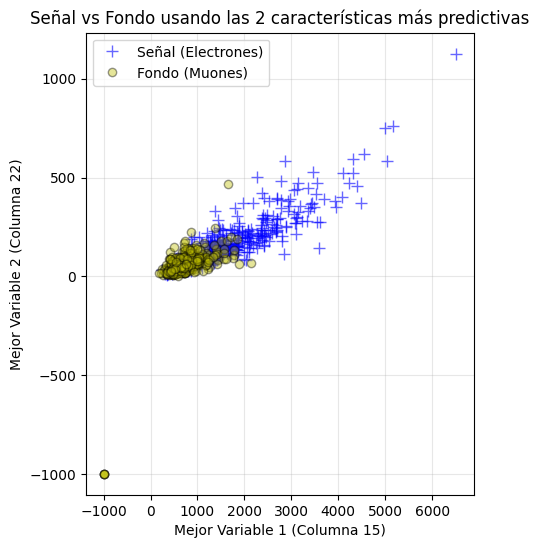

In [35]:
import warnings
warnings.filterwarnings("ignore") # Para evitar advertencias si alguna columna es constante

# 1. Encontrar automáticamente las 2 mejores variables (mayor correlación con y)
correlaciones = []
for i in range(X.shape[1]):
    # Calculamos la correlación entre la columna i y el vector y
    corr = np.corrcoef(X[:, i], y)[0, 1]
    # Guardamos el valor absoluto (nos importan correlaciones fuertes, sean positivas o negativas)
    correlaciones.append(abs(corr) if not np.isnan(corr) else 0)

# Obtenemos los índices de las 2 características con la correlación más alta
mejores_indices = np.argsort(correlaciones)[-2:]
col_mejor_1 = mejores_indices[1] # La #1 con más relación
col_mejor_2 = mejores_indices[0] # La #2 con más relación

print(f"Las variables más relacionadas con la aparición de un electrón son las columnas: {col_mejor_1} y {col_mejor_2}")

# =======================================================
# CÓDIGO PARA LLAMAR A LA GRÁFICA CON LAS MEJORES VARIABLES
# =======================================================

# Tomamos una muestra para no saturar la imagen (500 de clase 1, 500 de clase 0)
indices_clase_1 = np.where(y == 1)[0][:500]
indices_clase_0 = np.where(y == 0)[0][:500]
indices_muestra = np.concatenate([indices_clase_1, indices_clase_0])

# Filtramos X usando la muestra, y tomamos EXCLUSIVAMENTE las 2 mejores columnas
X_muestra = X[indices_muestra][:, [col_mejor_1, col_mejor_2]]
y_muestra = y[indices_muestra]

# Llamamos a tu función plotData (asegúrate de que la función plotData ya esté definida arriba)
pyplot.figure(figsize=(5,6 ))
plotData(X_muestra, y_muestra)

# Adicionamos etiquetas dinámicas
pyplot.xlabel(f'Mejor Variable 1 (Columna {col_mejor_1})')
pyplot.ylabel(f'Mejor Variable 2 (Columna {col_mejor_2})')

# Leyenda y título
pyplot.legend(['Señal (Electrones)', 'Fondo (Muones)'], loc='best')
pyplot.title('Señal vs Fondo usando las 2 características más predictivas')
pyplot.grid(True, alpha=0.3)
pyplot.show()

<a id="section1"></a>
### 1.2 Implementacion

#### 1.2.1 Fución Sigmoidea

La hipotesis para la regresión logistica se define como:

$$ h_\theta(x) = g(\theta^T x)$$

donde la función $g$ is la función sigmoidea. La función sigmoidea se define como:

$$g(z) = \frac{1}{1+e^{-z}}$$.

Los resultados que debe generar la funcion sigmoidea para valores positivos amplios de `x`, deben ser cercanos a 1, mientras que para valores negativos grandes, la sigmoide debe generar valores cercanos 0. La evaluacion de `sigmoid(0)` debe dar un resultado exacto de 0.5. Esta funcion tambien debe poder trabajar con vectores y matrices.

In [36]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

In [37]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    # Evitamos dividir por cero en caso de columnas constantes
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

En este paso, me aseguré de que todas las variables numéricas estuvieran en la misma escala, ya que las 50 características del dataset tenían rangos de medición muy distintos que podían desequilibrar y hacer muy lento el entrenamiento del modelo. Para solucionarlo, apliqué una función de normalización que toma mis datos de entrenamiento, calcula la media y la desviación estándar de cada columna, y ajusta los valores para que todos queden en un rango matemático uniforme. El resultado normalizado lo guardé en la variable X_norm para usarlo directamente en el algoritmo, y fue crucial también guardar la media (mu) y la desviación (sigma) calculadas aquí, ya que las necesitaré obligatoriamente más adelante para aplicar la misma transformación a mis datos de prueba y asegurar que las predicciones sean correctas.

In [38]:
print("Normalizando las características...")
X_norm, mu, sigma = featureNormalize(X)
print(X_norm)

Normalizando las características...
[[ 0.01992092  0.04066906 -0.50055166 ...  0.01763028  0.03223374
   0.0578474 ]
 [ 0.04195328  0.04375042 -0.5126002  ...  0.0259372   0.0367903
   0.05757935]
 [ 0.03365846  0.05335011 -0.42795614 ...  0.02729163  0.0354312
   0.05671253]
 ...
 [ 0.07739385  0.05389315  0.03516474 ...  0.10656401  0.04672897
   0.05614091]
 [ 0.06824428  0.06618425  0.07738959 ...  0.11191242  0.07810462
   0.05638655]
 [ 0.06352252  0.09077461 -0.29568401 ...  0.04884532  0.08765997
   0.05772953]]


En este paso preparé la matriz de entrenamiento final agregando un elemento matemático clave para que el algoritmo funcione correctamente. Primero, extraje la cantidad exacta de filas y columnas de mis datos ya normalizados; luego, generé una nueva columna llena únicamente con números "1" y la pegué justo al principio de mi matriz de características. Hice esto porque el modelo de regresión logística necesita este valor constante (conocido como término de sesgo, intersección o bias) para poder calcular correctamente el punto de corte de la fórmula matemática al multiplicar las matrices

In [39]:
m, n = X_norm.shape
X_entrenamiento = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

<a id="section2"></a>
#### 1.2.2 Función de Costo y Gradiente

Se implementa la funcion cost y gradient, para la regresión logistica. Antes de continuar es importante agregar el termino de intercepcion a X.

La funcion de costo en una regresión logistica es:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

y el gradiente del costo es un vector de la misma longitud como $\theta$ donde el elemento $j^{th}$ (para $j = 0, 1, \cdots , n$) se define como:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

Si bien este gradiente parece idéntico al gradiente de regresión lineal, la fórmula es diferente porque la regresión lineal y logística tienen diferentes definiciones de $h_\theta(x)$.
<a id="costFunction"></a>

In [40]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

En este paso, programé una función matemática específica llamada calcular_precision para poder evaluar en cualquier momento qué tan exactas son las predicciones de mi modelo. Para lograrlo, diseñé el código para que primero procese los datos a través de la función sigmoide y calcule las probabilidades; luego, establecí una regla lógica estricta donde cualquier probabilidad igual o mayor al 50% se clasifica automáticamente como una señal verdadera (1) y todo lo que esté por debajo se clasifica como fondo (0). Por último, hice que el programa compare mis predicciones una por una con las etiquetas reales originales, lo que me permite calcular el promedio matemático de coincidencias y obtener el porcentaje exacto de aciertos que tiene el algoritmo

In [41]:
def calcular_precision(theta, X, y):
    # Calculamos las probabilidades
    h = sigmoid(X.dot(theta.T))
    # Convertimos probabilidades a 1 o 0 (umbral de 0.5)
    p = (h >= 0.5).astype(int)
    # Calculamos el porcentaje de aciertos
    precision = np.mean(p == y) * 100
    return precision

programé el algoritmo de Descenso por Gradiente para que el modelo aprenda de forma iterativa. En cada una de las 10,000 repeticiones, el código calcula las predicciones actuales mediante la función sigmoide y ajusta los pesos ($\theta$) basándose en el error cometido, moviéndose siempre en la dirección que minimiza la función de costo. Para tener un control total del proceso, incluí un sistema de monitoreo que guarda tanto el historial de errores como el porcentaje de precisión en cada paso, imprimiendo el progreso cada 1,000 iteraciones para verificar visualmente que el costo esté bajando y la exactitud subiendo

In [42]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()

    # Listas para guardar el historial
    J_history = []
    acc_history = [] # NUEVO: Aquí guardaremos la precisión

    for i in range(num_iters):
        # Actualizamos los pesos
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        # Guardamos el costo
        costo_actual = calcularCosto(theta, X, y)
        J_history.append(costo_actual)

        # NUEVO: Calculamos y guardamos la precisión en esta iteración
        precision_actual = calcular_precision(theta, X, y)
        acc_history.append(precision_actual)

        # Imprimimos el progreso
        if i % 1000 == 0:
            print(f"Iteración {i}: Costo J = {costo_actual:.4f} | Precisión = {precision_actual:.2f}%")

    return theta, J_history, acc_history

En este paso llevé a cabo el entrenamiento real de mi modelo; para ello, configuré los parámetros iniciales definiendo una tasa de aprendizaje de 0.5, un límite de 10,000 iteraciones y un conjunto de pesos iniciales en cero. Tras establecer estos valores, ejecuté mi función de descenso por gradiente, la cual fue ajustando iteración tras iteración los parámetros matemáticos para minimizar los errores y aprender a distinguir correctamente las señales del fondo. Finalmente, para demostrar de forma visual que el algoritmo realmente aprendió durante este proceso, programé la generación de dos gráficas simultáneas: la primera evidencia cómo el costo o margen de error matemático disminuye drásticamente con el tiempo, mientras que la segunda confirma cómo mi porcentaje de precisión va subiendo continuamente hasta estabilizarse en su punto máximo, validando el éxito total del entrenamiento.

Entrenando el modelo y calculando métricas...
Iteración 0: Costo J = 0.6333 | Precisión = 80.52%
Iteración 1000: Costo J = 0.3685 | Precisión = 83.75%
Iteración 2000: Costo J = 0.3652 | Precisión = 83.95%
Iteración 3000: Costo J = 0.3626 | Precisión = 84.16%
Iteración 4000: Costo J = 0.3606 | Precisión = 84.29%
Iteración 5000: Costo J = 0.3588 | Precisión = 84.41%
Iteración 6000: Costo J = 0.3573 | Precisión = 84.54%
Iteración 7000: Costo J = 0.3560 | Precisión = 84.64%
Iteración 8000: Costo J = 0.3547 | Precisión = 84.72%
Iteración 9000: Costo J = 0.3536 | Precisión = 84.82%
¡Listo! Precisión final en entrenamiento: 84.89%


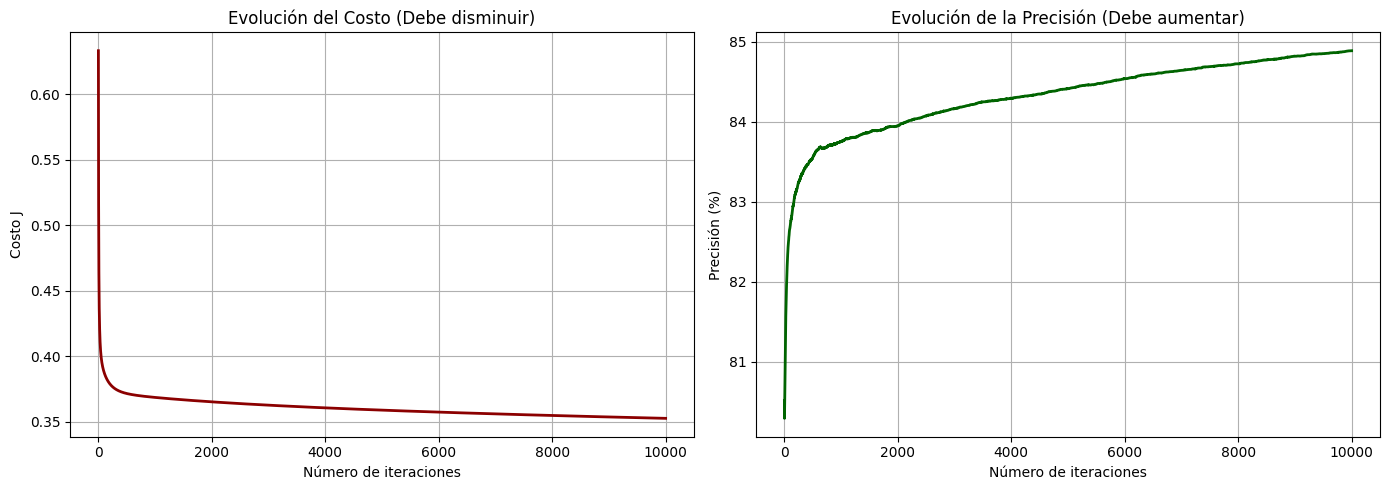

In [43]:
alpha = 0.5
num_iters = 10000
theta_inicial = np.zeros(X_entrenamiento.shape[1])

print("Entrenando el modelo y calculando métricas...")
theta_optimo, J_history, acc_history = descensoGradiente(theta_inicial, X_entrenamiento, y, alpha, num_iters)
print(f"¡Listo! Precisión final en entrenamiento: {acc_history[-1]:.2f}%")

# =====================================================================
# 5. GRAFICANDO COSTO Y PRECISIÓN LADO A LADO
# =====================================================================
pyplot.figure(figsize=(14, 5))

# Gráfica 1: Costo (Debe ir bajando)
pyplot.subplot(1, 2, 1) # 1 fila, 2 columnas, gráfica 1
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='darkred')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Evolución del Costo (Debe disminuir)')
pyplot.grid(True)

# Gráfica 2: Precisión (Debe ir subiendo)
pyplot.subplot(1, 2, 2) # 1 fila, 2 columnas, gráfica 2
pyplot.plot(np.arange(len(acc_history)), acc_history, lw=2, color='darkgreen')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Precisión (%)')
pyplot.title('Evolución de la Precisión (Debe aumentar)')
pyplot.grid(True)

pyplot.tight_layout() # Para que no se sobrepongan los textos
pyplot.show()

puse a prueba mi modelo utilizando el 20% de los datos que reservé al principio y que el algoritmo nunca había visto. Para que la evaluación fuera justa, primero normalicé estas características de prueba usando exactamente la misma media y desviación estándar que calculé con los datos de entrenamiento, y añadí la columna de unos para el término de sesgo. Finalmente, programé un ciclo que recorre estas filas, calcula la probabilidad de que cada evento sea una señal mediante la función sigmoide y los pesos óptimos encontrados, e imprime el resultado junto al valor real para verificar visualmente que las predicciones del modelo coinciden con la realidad del experimento físico.

In [48]:
print('valores de theta calculados: ', theta_optimo)
m_test=X_test.shape[0]
X_test_norm = (X_test - mu) / sigma
X_test_1 = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)
# Prueba con la Fila 0 (Sabemos que es Señal)
for i in range(X_test_1.shape[0]):

    # 2. Calculamos la probabilidad para esa fila específica
    prob_senial = sigmoid(np.dot(X_test_1[i], theta_optimo))

    # 3. Extraemos el valor real de y_test para poder comparar
    valor_real = int(y_test[i])

    # 4. Imprimimos el resultado dinámicamente usando la f-string
    print(f'Fila {i} | Valor Real: {valor_real} | Probabilidad si existe senal: {prob_senial :.2f}')

Se han truncado las últimas 5000 líneas del flujo de salida.
Fila 21013 | Valor Real: 0 | Probabilidad si existe senal: 0.22
Fila 21014 | Valor Real: 0 | Probabilidad si existe senal: 0.06
Fila 21015 | Valor Real: 0 | Probabilidad si existe senal: 0.04
Fila 21016 | Valor Real: 0 | Probabilidad si existe senal: 0.21
Fila 21017 | Valor Real: 0 | Probabilidad si existe senal: 0.34
Fila 21018 | Valor Real: 0 | Probabilidad si existe senal: 0.62
Fila 21019 | Valor Real: 0 | Probabilidad si existe senal: 0.12
Fila 21020 | Valor Real: 0 | Probabilidad si existe senal: 0.03
Fila 21021 | Valor Real: 0 | Probabilidad si existe senal: 0.09
Fila 21022 | Valor Real: 0 | Probabilidad si existe senal: 0.03
Fila 21023 | Valor Real: 0 | Probabilidad si existe senal: 0.64
Fila 21024 | Valor Real: 0 | Probabilidad si existe senal: 0.03
Fila 21025 | Valor Real: 0 | Probabilidad si existe senal: 0.28
Fila 21026 | Valor Real: 0 | Probabilidad si existe senal: 0.00
Fila 21027 | Valor Real: 0 | Probabilidad s